# ANÁLISIS EXPLORATORIO Y TRANSFORMACIÓN DE DATOS

### Librerias y Carga de datos


In [53]:
# Instalación de librerías para EDA de datos médicos
!pip install pandas numpy matplotlib seaborn plotly
!pip install scikit-learn scipy
!pip install missingno # Para visualización de datos faltantes
!pip install sweetviz # Para reportes automáticos de EDA
!pip install pandas-profiling # Para perfilado automático de datos
!pip install imbalanced-learn # Para manejo de datos desbalanceados
!pip install openpyxl # Para leer archivos Excel si es necesario


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the s

In [54]:
# Importación de librerías esenciales para EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import re
import unicodedata
from plotly.subplots import make_subplots


# Para análisis estadístico
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Para visualización de datos faltantes
# import missingno as msno

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Configuración de warnings
import warnings
warnings.filterwarnings('ignore')

In [55]:
df = pd.read_excel('../../data.xlsx')

print(f"  - Filas: {df.shape[0]}")
print(f"  - Columnas: {df.shape[1]}")

# Verificar valores nulos por columna
print(df.isnull().sum())


  - Filas: 3984
  - Columnas: 11
Fecha(dd/mm/yyyy)                  0
Modalidad                          0
Estudio                            0
Técnica                            3
Datos Clínicos                     6
Hallazgos                          4
Opinión                            4
Reporte estructurado               0
Estudio Complementario Sugerido    0
Hallazgo Crítico                   0
Estudio Normal                     1
dtype: int64


In [56]:
df['Datos Clínicos'] = df['Datos Clínicos'].fillna('NR')
df['Técnica'] = df['Técnica'].fillna('NR')
df['Estudio Normal'] = df['Estudio Normal'].fillna(0)
# Eliminamos las filas con nulos en 'Hallazgos' o 'Opinión'
df = df.dropna(subset=['Hallazgos', 'Opinión'])
# Verificar valores nulos después de la limpieza
print(df.isnull().sum())

Fecha(dd/mm/yyyy)                  0
Modalidad                          0
Estudio                            0
Técnica                            0
Datos Clínicos                     0
Hallazgos                          0
Opinión                            0
Reporte estructurado               0
Estudio Complementario Sugerido    0
Hallazgo Crítico                   0
Estudio Normal                     0
dtype: int64


In [57]:
# Columnas de texto no estructurado a normalizar
text_columns = ['Técnica', 'Datos Clínicos', 'Hallazgos', 'Opinión']

for col in text_columns:
    # Convertir a string (por si hay valores numéricos o NaN)
    df[col] = df[col].astype(str)
    
    # Convertir a minúsculas
    df[col] = df[col].str.lower()
    
    # Eliminar espacios extra al inicio y final
    df[col] = df[col].str.strip()
    
    # Reemplazar múltiples espacios por un solo espacio
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)
    
    # Normalizar puntuación: agregar espacio después de puntos, comas, etc.
    df[col] = df[col].str.replace(r'([.,:;!?])', r'\1 ', regex=True)
    
    # Eliminar espacios extra nuevamente
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)

print("Normalización de texto no estructurado completada")

Normalización de texto no estructurado completada


In [58]:
# Verificar distribución de valores binarios
print("Distribución de Hallazgo Crítico:")
print(df['Hallazgo Crítico'].value_counts())

print("\nDistribución de Estudio Normal:")
print(df['Estudio Normal'].value_counts())

print("\nDistribución de Reporte estructurado:")
print(df['Reporte estructurado'].value_counts())

print("\nDistribución de Estudio Complementario Sugerido:")
print(df['Estudio Complementario Sugerido'].value_counts())

Distribución de Hallazgo Crítico:
Hallazgo Crítico
0    3082
1     895
Name: count, dtype: int64

Distribución de Estudio Normal:
Estudio Normal
0.0    2527
1.0    1450
Name: count, dtype: int64

Distribución de Reporte estructurado:
Reporte estructurado
0    3160
1     817
Name: count, dtype: int64

Distribución de Estudio Complementario Sugerido:
Estudio Complementario Sugerido
0    3837
1     140
Name: count, dtype: int64


In [63]:
for col in ['Modalidad', 'Estudio', 'Técnica', 'Reporte estructurado', 'Estudio Complementario Sugerido', 'Hallazgo Crítico', 'Estudio Normal']:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())


Modalidad value counts:
Modalidad
CT    3977
Name: count, dtype: int64

Estudio value counts:
Estudio
tomografia computada de craneo simple                                        3970
tomografia computada de craneo con contraste                                    3
tomografia computada de craneo y columna cervical simple                        2
tomografia computada de craneo simple con angiotac de arterias cerebrales       1
tac de craneo simple recien nacidos                                             1
Name: count, dtype: int64

Técnica value counts:
Técnica
se realizan cortes axiales desde fosa posterior hasta el vértex, en forma simple.                                                                                                                                                                                                                                                                            1172
en equipo multidetector, se realizan cortes axiales desde la base del cráneo

In [64]:
def remove_accents(text):
    return ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

def normalize_estudio(value):
    v = str(value).lower().strip()
    v = remove_accents(v)
    v = re.sub(r'\s+', ' ', v)
    v = v.replace('.', '')  # Elimina puntos finales
    # Angiotac (debe ir antes de "simple")
    if 'angiotac' in v:
        return 'tomografia computada de craneo simple con angiotac de arterias cerebrales'
    # Agrupar variantes de "simple"
    if re.search(r'tomografia computada de craneo simple', v) or \
        re.search(r'tomografia computada de craneo simpl', v) or \
        re.search(r'tomografia computada de craneo$', v) or \
        re.search(r'tomografia computada de crane$', v) or \
        re.search(r'tomografia computada de craneo simplev', v) or\
        re.search(r'tomografia axial computarizada de craneo simple dentro de limites normales', v) or\
        re.search(r'trauma craneoencefalico, cefalea y emesis', v) or\
        re.search(r'computada de craneo simple', v):
            return 'tomografia computada de craneo simple'
    # Agrupar variantes de "con contraste"
    if 'contraste' in v:
        return 'tomografia computada de craneo con contraste'
    # Agrupar columna cervical
    if 'columna cervical' in v:
        return 'tomografia computada de craneo y columna cervical simple'
    # TAC de recien nacidos
    if 'recien nacidos' in v:
        return 'tac de craneo simple recien nacidos'
    # Trauma, cefalea, emesis (caso único)
    if 'trauma' in v or 'cefalea' in v or 'emesis' in v:
        return v  # Mantener tal cual, es un caso único
    # Si nada coincide, devolver el valor normalizado
    return v

df['Estudio'] = df['Estudio'].apply(normalize_estudio)
print(df['Estudio'].value_counts())

Estudio
tomografia computada de craneo simple                                        3970
tomografia computada de craneo con contraste                                    3
tomografia computada de craneo y columna cervical simple                        2
tomografia computada de craneo simple con angiotac de arterias cerebrales       1
tac de craneo simple recien nacidos                                             1
Name: count, dtype: int64


In [65]:
df.to_excel('../../data_cleaned.xlsx', index=False)
print("Archivo normalizado guardado como 'data_cleaned.xlsx'")

# información final
print(f"\nDataFrame final:")
print(f"  - Filas: {df.shape[0]}")
print(f"  - Columnas: {df.shape[1]}")
print(f"\nValores nulos finales:")
print(df.isnull().sum())

Archivo normalizado guardado como 'data_cleaned.xlsx'

DataFrame final:
  - Filas: 3977
  - Columnas: 11

Valores nulos finales:
Fecha(dd/mm/yyyy)                  0
Modalidad                          0
Estudio                            0
Técnica                            0
Datos Clínicos                     0
Hallazgos                          0
Opinión                            0
Reporte estructurado               0
Estudio Complementario Sugerido    0
Hallazgo Crítico                   0
Estudio Normal                     0
dtype: int64



Reporte estructurado:
Reporte estructurado
0    3160
1     817
Name: count, dtype: int64
Proporción de 1: 0.20543122957002766

Estudio Complementario Sugerido:
Estudio Complementario Sugerido
0    3837
1     140
Name: count, dtype: int64
Proporción de 1: 0.0352024138798089

Hallazgo Crítico:
Hallazgo Crítico
0    3082
1     895
Name: count, dtype: int64
Proporción de 1: 0.22504400301734975

Estudio Normal:
Estudio Normal
0.0    2527
1.0    1450
Name: count, dtype: int64
Proporción de 1: 0.3645964294694493


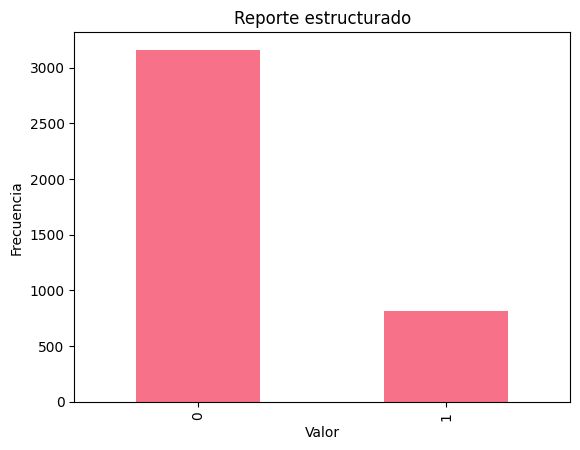

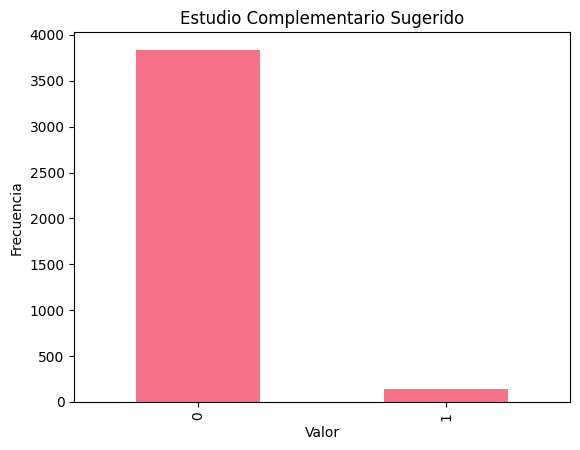

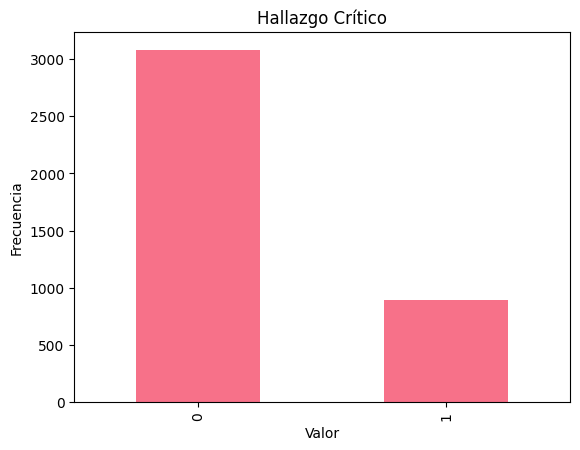

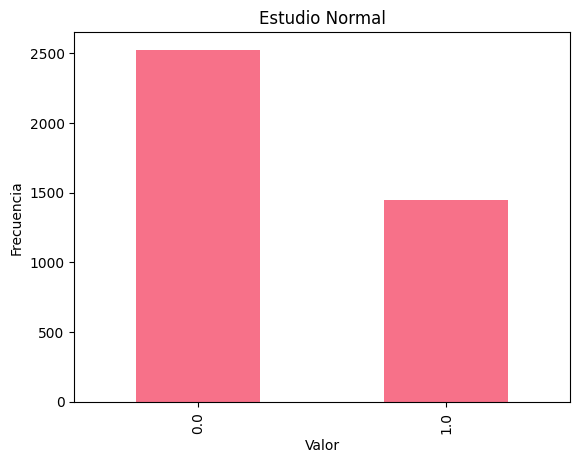

In [71]:
binary_cols = ['Reporte estructurado', 'Estudio Complementario Sugerido', 'Hallazgo Crítico', 'Estudio Normal']

for col in binary_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print("Proporción de 1:", df[col].mean())

for col in binary_cols:
    df[col].value_counts().plot(kind='bar', title=col)
    plt.xlabel('Valor')
    plt.ylabel('Frecuencia')
    plt.show()

In [75]:
# Muestra aleatoria de hallazgos y opiniones
print(df['Hallazgos'].sample(20, random_state=1))
print(df['Opinión'].sample(20, random_state=1))

# Palabras más frecuentes en Hallazgos
from collections import Counter
import re

all_text = ' '.join(df['Hallazgos'].dropna().astype(str).tolist()).lower()
words = re.findall(r'\b\w+\b', all_text)
counter = Counter(words)
print(counter.most_common(50))  # 50 palabras más frecuentes

# Frases de 2-3 palabras más frecuentes (n-gramas)
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,3), max_features=50)
X = vectorizer.fit_transform(df['Hallazgos'].dropna().astype(str).str.lower())
ngrams = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1
ngram_freq = sorted(zip(ngrams, counts), key=lambda x: -x[1])
print(ngram_freq)

3047    surcos y circunvoluciones simétricos. sistema ...
1064    prominencia de los surcos en las convejidades ...
1889    prominencia surcos, circunvoluciones y espacio...
1759    parénquima cerebral de densidad homogénea, sin...
1674    hemorragia intraparenquimatosa: no. signos de ...
419     parénquima cerebral de densidad homogénea, sin...
950     surcos y circunvoluciones simétricos. sistema ...
788     surcos y circunvoluciones simétricos prominent...
861     surcos y circunvoluciones simétricos. sistema ...
1539    colecciones extra-axiales subdurales crónicas ...
2565    la hipodensidad la sustancia blanca periventri...
494     surcos y circunvoluciones simétricos y promine...
3269    hemorragia intraparenquimatosa: no. signos de ...
2442    surcos y espacio subaracnoideo prominente por ...
3029    surcos y espacios subaracnoideos prominentes p...
3593    signos de sangrado. hematoma subdural: si, fro...
689     prominencia de los surcos en las convejidades ...
1406    surcos

### Distribución de variables binarias

- **Reporte estructurado:** Solo el 20.5% de los reportes están estructurados, lo que evidencia la necesidad de técnicas de PLN para analizar la mayoría de los informes.
- **Estudio Complementario Sugerido:** Apenas el 3.5% de los estudios sugieren un estudio adicional, mostrando un fuerte desbalance de clases.
- **Hallazgo Crítico:** El 22.5% de los estudios presentan hallazgos críticos, lo que resalta la importancia de su detección automática.
- **Estudio Normal:** El 36.5% de los estudios son normales, mientras que el resto presenta alguna alteración.

Estas proporciones permiten dimensionar el reto del análisis automático y la relevancia clínica de cada variable.

In [76]:
ct = pd.crosstab(df['Hallazgo Crítico'], df['Estudio Complementario Sugerido'])
print(ct)

Estudio Complementario Sugerido     0   1
Hallazgo Crítico                         
0                                2989  93
1                                 848  47


- La mayoría de los estudios con hallazgo crítico no sugieren un estudio complementario (848 vs 47).
- Solo el 5.2% (47/895) de los estudios con hallazgo crítico sugieren un estudio complementario.
Esto puede indicar que no todos los hallazgos críticos requieren seguimiento inmediato, o que la recomendación no siempre se documenta.

In [77]:
ct = pd.crosstab(df['Reporte estructurado'], df['Hallazgo Crítico'])
print(ct)

Hallazgo Crítico         0    1
Reporte estructurado           
0                     2536  624
1                      546  271


- Tanto en reportes estructurados como no estructurados, hay hallazgos críticos.
- La proporción de hallazgos críticos es ligeramente mayor en reportes estructurados (271/817 ≈ 33%) que en no estructurados (624/3160 ≈ 20%).
- Esto puede indiciar que los reportes estructurados pueden facilitar la identificación o documentación de hallazgos críticos.
